# EDA: Echoes of Silenced Genes

Exploratory data analysis and visualizations for the competition.

All figures are saved to `outputs/figures/`.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import os

import config
from data_utils import (
    load_adata, load_ground_truth, load_pert_ids,
    load_means, compute_wmae, compute_wmae_per_pert
)

config.make_dirs()
FIGURES = config.FIGURES_DIR
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
adata = load_adata()
de_matrix, weight_matrix, gene_order, pert_order = load_ground_truth()
means_df, _ = load_means()
perts_all = load_pert_ids()

print(f'h5ad:       {adata.shape}')
print(f'DE matrix:  {de_matrix.shape}')
print(f'Weights:    {weight_matrix.shape}')
print(f'Test perts: {len(perts_all)} ({perts_all["class"].value_counts().to_dict()})')

# Sanity check baseline WMAE
baseline_pred = np.tile(de_matrix.mean(axis=0, keepdims=True), (de_matrix.shape[0], 1))
print(f'Baseline WMAE (mean DE): {compute_wmae(baseline_pred, de_matrix, weight_matrix):.4f}')

Loading h5ad …
  17882 cells × 19226 genes
Ground truth: 80 perturbations × 5127 genes
h5ad:       (17882, 19226)
DE matrix:  (80, 5127)
Weights:    (80, 5127)
Test perts: 120 ({'val': 60, 'test': 60})
Baseline WMAE (mean DE): 0.1268


## 2. DE Value Distribution

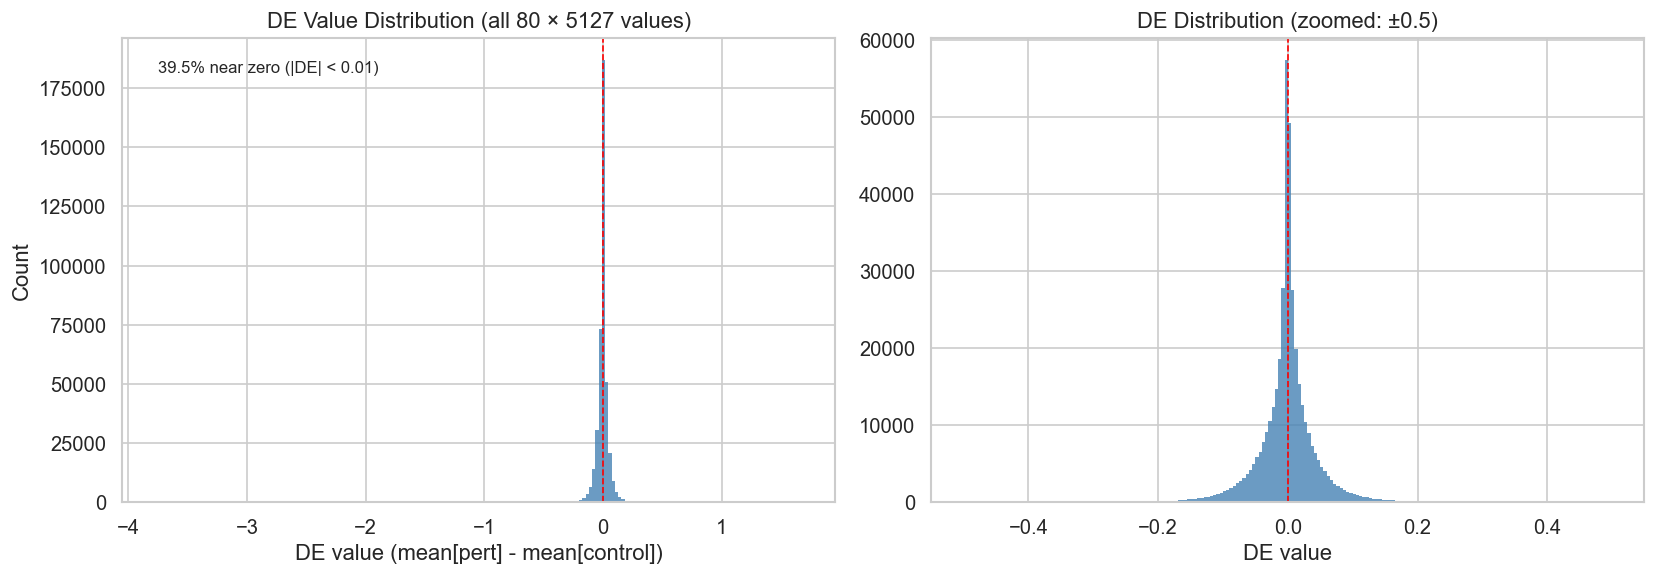

DE stats: mean=-0.0018, std=0.0569, max|DE|=3.7784


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
de_flat = de_matrix.flatten()
axes[0].hist(de_flat, bins=200, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].set_xlabel('DE value (mean[pert] - mean[control])')
axes[0].set_ylabel('Count')
axes[0].set_title('DE Value Distribution (all 80 × 5127 values)')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
pct_near_zero = (np.abs(de_flat) < 0.01).mean() * 100
axes[0].text(0.05, 0.95, f'{pct_near_zero:.1f}% near zero (|DE| < 0.01)',
             transform=axes[0].transAxes, va='top', fontsize=10)

# Zoomed in
axes[1].hist(de_flat, bins=200, range=(-0.5, 0.5), color='steelblue', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('DE value')
axes[1].set_title('DE Distribution (zoomed: ±0.5)')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '01_de_distribution.png'), bbox_inches='tight')
plt.show()
print(f'DE stats: mean={de_flat.mean():.4f}, std={de_flat.std():.4f}, max|DE|={np.abs(de_flat).max():.4f}')

## 3. Per-Perturbation Difficulty

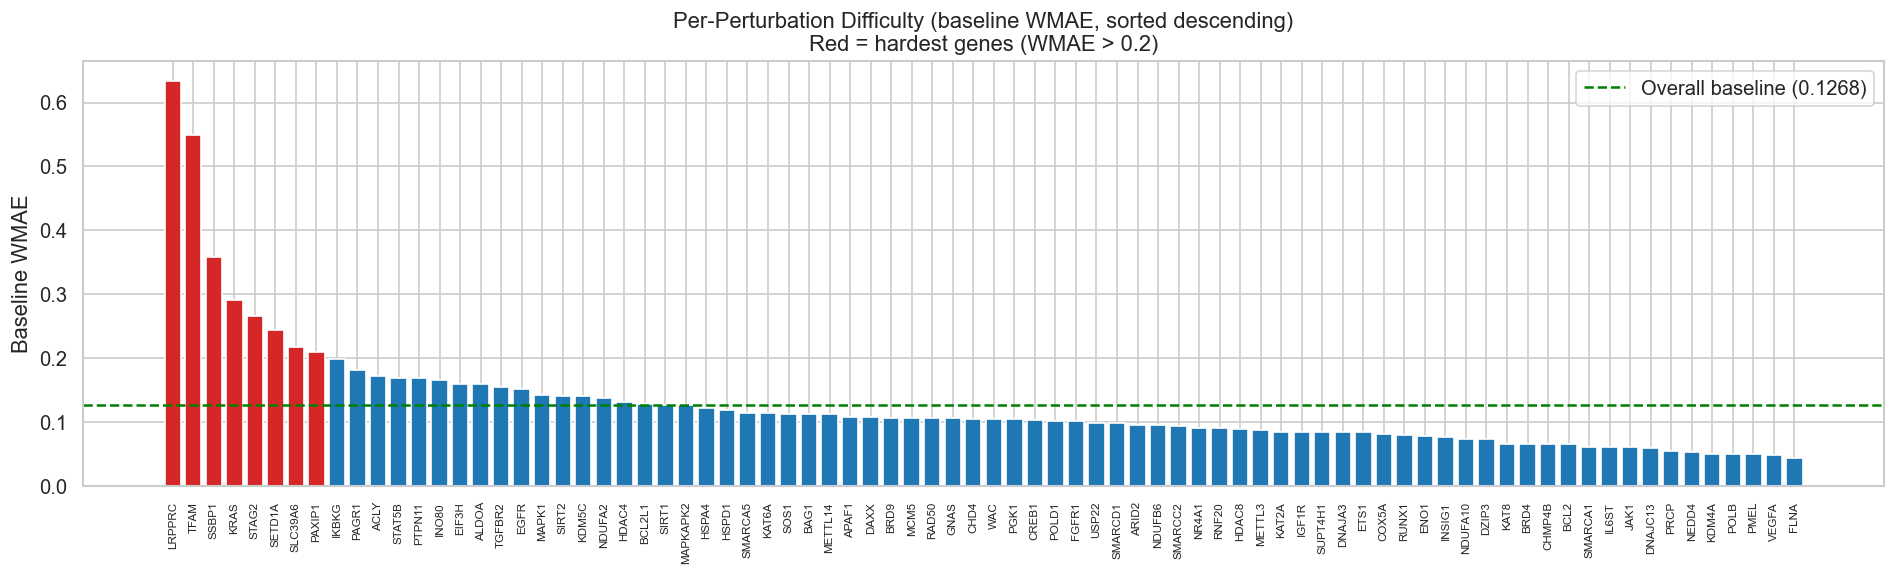

Hardest genes (WMAE > 0.2): 8
    pert_id  baseline_wmae
40   LRPPRC       0.633442
75     TFAM       0.549520
71    SSBP1       0.357669
39     KRAS       0.290600
72    STAG2       0.264928
62   SETD1A       0.243733
65  SLC39A6       0.217860
52   PAXIP1       0.209861


In [4]:
# Baseline WMAE per perturbation (from the GT table)
gt_df = pd.read_csv(config.GT_PATH)
baseline_wmae_per_pert = gt_df[['pert_id', 'baseline_wmae']].copy()
baseline_wmae_per_pert = baseline_wmae_per_pert.sort_values('baseline_wmae', ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#d62728' if v > 0.2 else '#1f77b4' for v in baseline_wmae_per_pert['baseline_wmae']]
ax.bar(range(len(baseline_wmae_per_pert)), baseline_wmae_per_pert['baseline_wmae'], color=colors)
ax.set_xticks(range(len(baseline_wmae_per_pert)))
ax.set_xticklabels(baseline_wmae_per_pert['pert_id'], rotation=90, fontsize=7)
ax.set_ylabel('Baseline WMAE')
ax.set_title('Per-Perturbation Difficulty (baseline WMAE, sorted descending)\nRed = hardest genes (WMAE > 0.2)')
ax.axhline(0.1268, color='green', linestyle='--', linewidth=1.5, label='Overall baseline (0.1268)')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '02_pert_difficulty.png'), bbox_inches='tight')
plt.show()

print(f'Hardest genes (WMAE > 0.2): {(baseline_wmae_per_pert["baseline_wmae"] > 0.2).sum()}')
print(baseline_wmae_per_pert[baseline_wmae_per_pert['baseline_wmae'] > 0.2])

## 4. DE Heatmap (Functional Clusters)

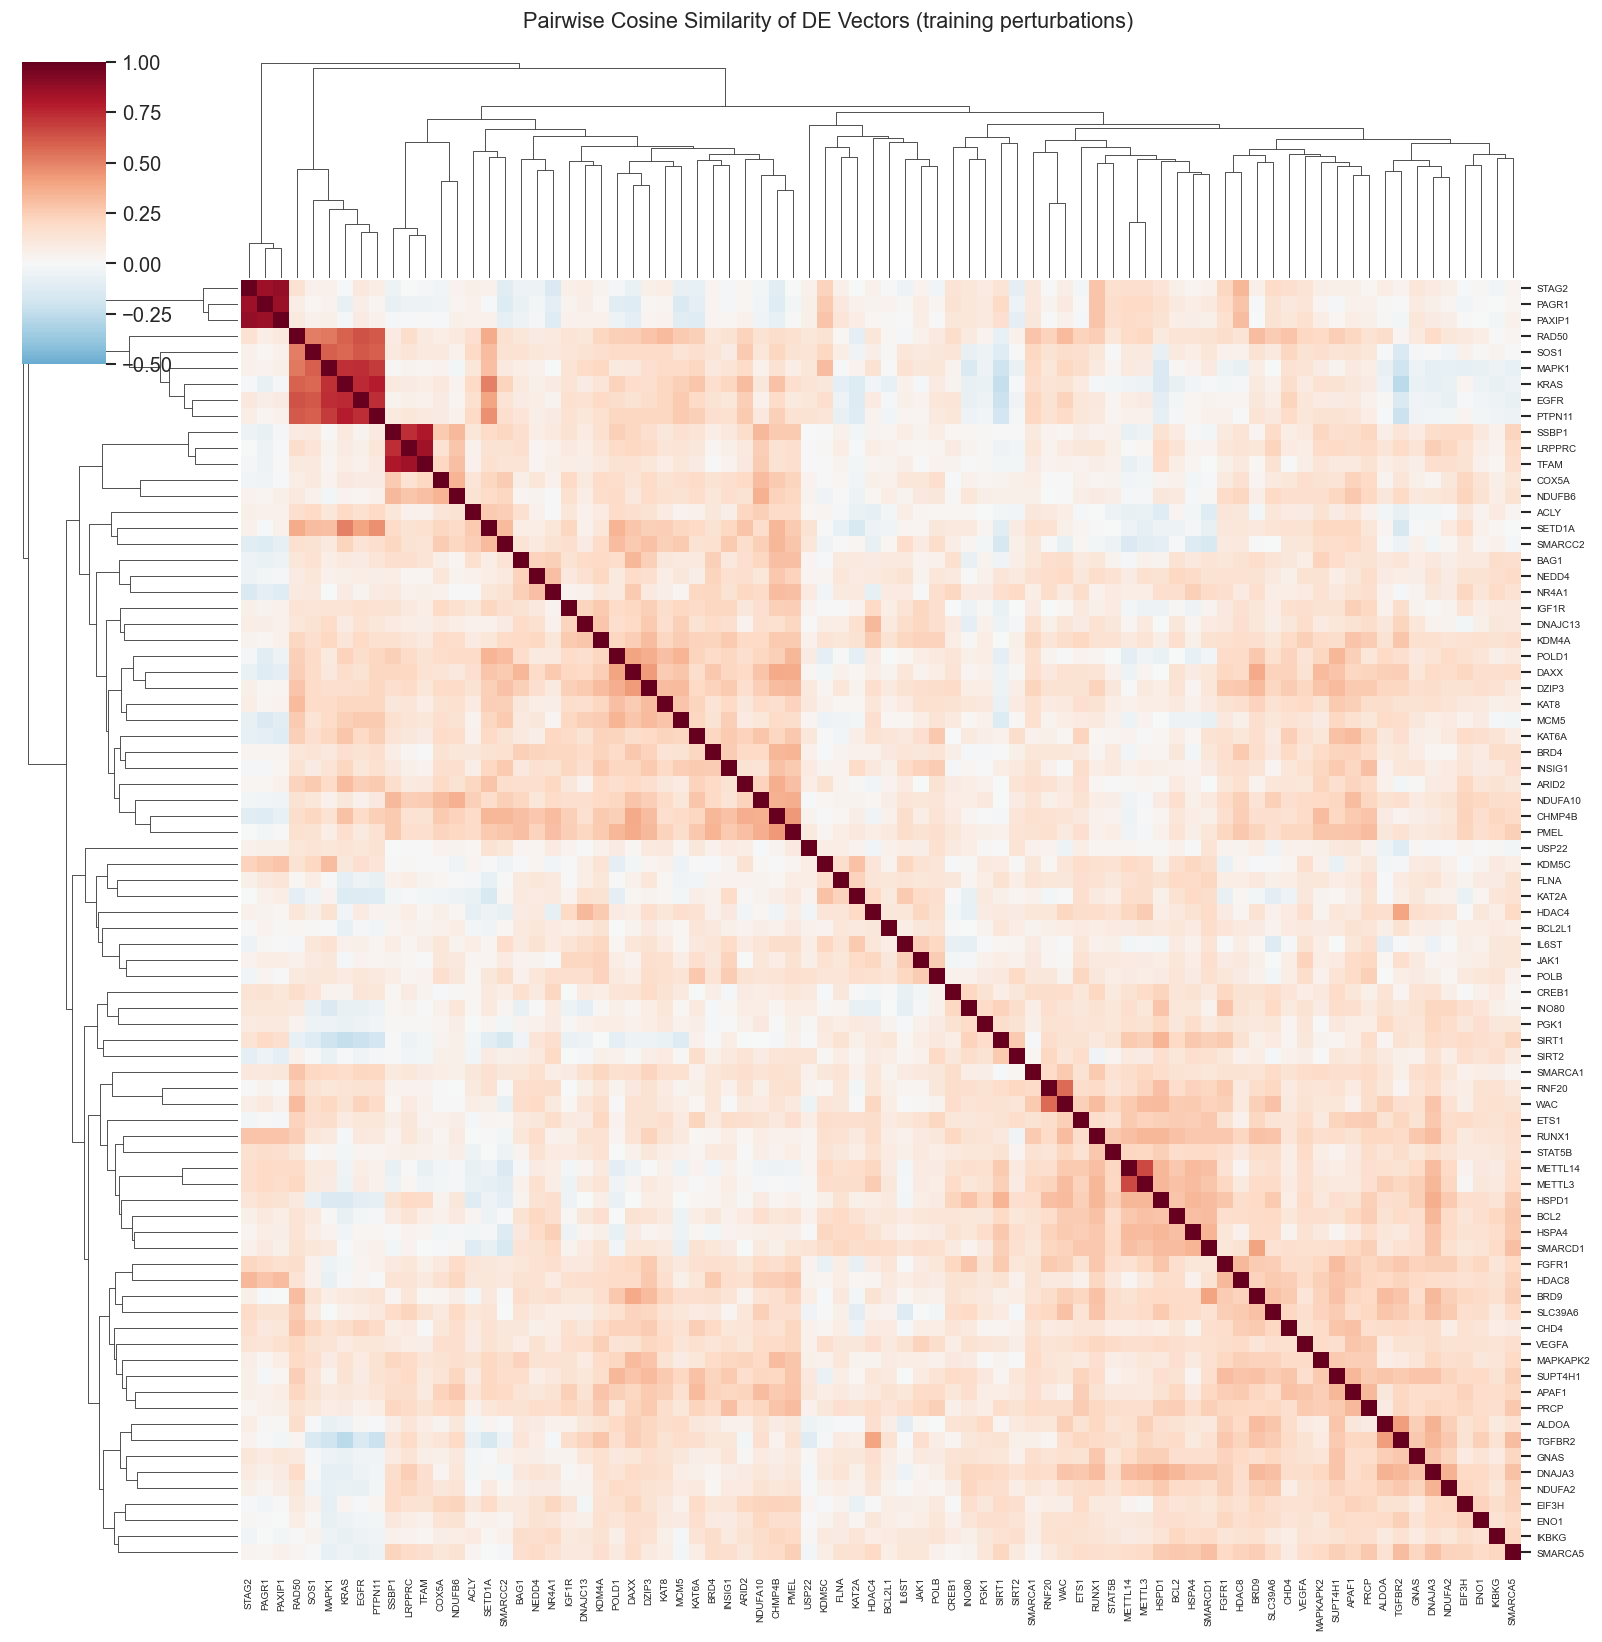

Most similar training perturbation pairs:
  PAXIP1 ↔ STAG2: 0.876
  PAGR1 ↔ PAXIP1: 0.861
  PAGR1 ↔ STAG2: 0.849
  LRPPRC ↔ TFAM: 0.844
  SSBP1 ↔ TFAM: 0.808


In [5]:
# Compute pairwise cosine similarity between training perturbations
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(de_matrix)  # (80, 80)
cos_df = pd.DataFrame(cos_sim, index=pert_order, columns=pert_order)

# Clustermap
g = sns.clustermap(
    cos_df,
    cmap='RdBu_r',
    center=0,
    vmin=-0.5, vmax=1.0,
    figsize=(14, 14),
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=0.15,
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=6)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)
g.figure.suptitle('Pairwise Cosine Similarity of DE Vectors (training perturbations)', 
                   y=1.01, fontsize=13)

plt.savefig(os.path.join(FIGURES, '03_de_clustermap.png'), bbox_inches='tight')
plt.show()

# Find most similar pairs
np.fill_diagonal(cos_sim, 0)
top_pairs_idx = np.argsort(cos_sim.flatten())[-10:]
print('Most similar training perturbation pairs:')
for idx in top_pairs_idx[::-1]:
    i, j = idx // 80, idx % 80
    if i < j:
        print(f'  {pert_order[i]} ↔ {pert_order[j]}: {cos_sim[i,j]:.3f}')

## 5. Weight Distribution

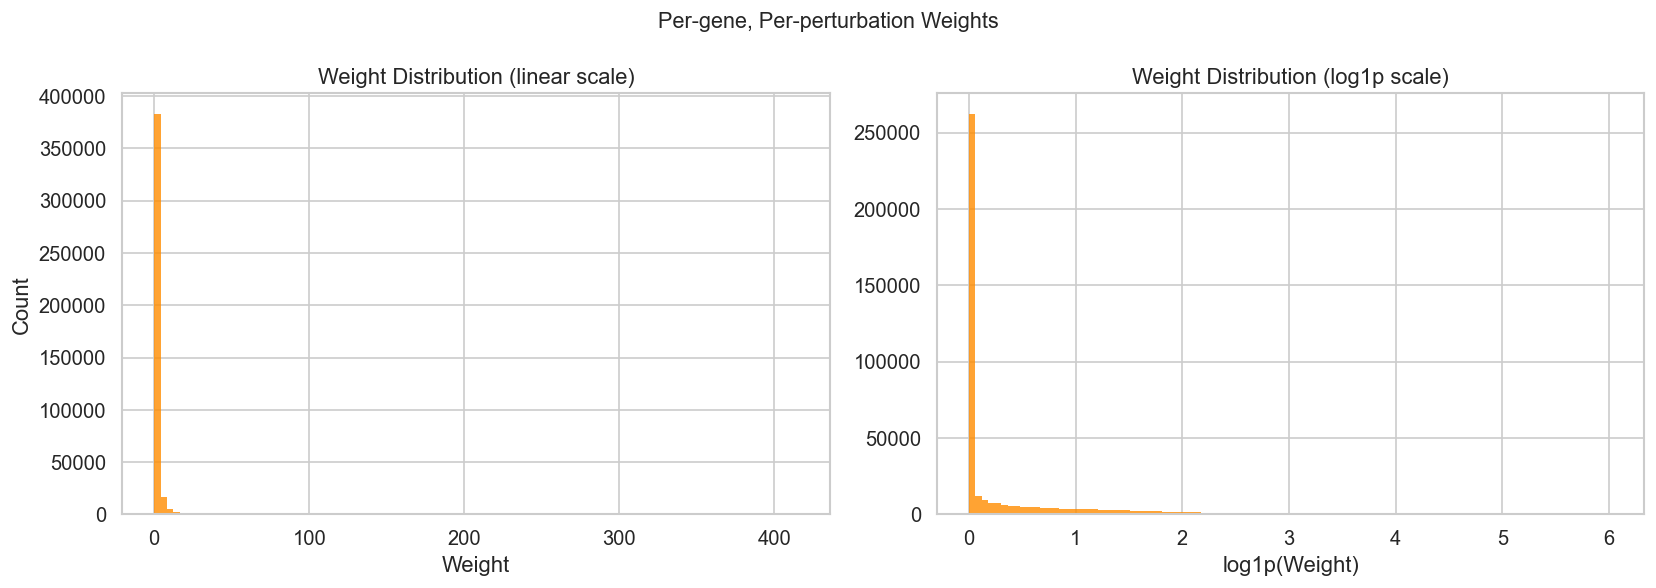

Weight stats: mean=1.000, median=0.035
  >1.0: 18.8% of weights
  >5.0: 5.23% of weights
  max:  415.00

Top-10 highest mean-weight genes:
  MUC5AC: 10.025
  TPM1: 9.754
  MT2A: 9.693
  EEF1A2: 9.124
  PMEPA1: 9.048
  DKK1: 8.637
  SERPINE1: 8.539
  ALDH3A1: 8.273
  ALDH1A1: 8.148
  CXCL5: 7.987


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

w_flat = weight_matrix.flatten()

# Linear scale
axes[0].hist(w_flat, bins=100, color='darkorange', alpha=0.8, edgecolor='none')
axes[0].set_xlabel('Weight')
axes[0].set_ylabel('Count')
axes[0].set_title('Weight Distribution (linear scale)')

# Log scale
axes[1].hist(np.log1p(w_flat), bins=100, color='darkorange', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('log1p(Weight)')
axes[1].set_title('Weight Distribution (log1p scale)')

plt.suptitle('Per-gene, Per-perturbation Weights', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '04_weight_distribution.png'), bbox_inches='tight')
plt.show()

print(f'Weight stats: mean={w_flat.mean():.3f}, median={np.median(w_flat):.3f}')
print(f'  >1.0: {(w_flat > 1.0).mean()*100:.1f}% of weights')
print(f'  >5.0: {(w_flat > 5.0).mean()*100:.2f}% of weights')
print(f'  max:  {w_flat.max():.2f}')

# Top-10 highest-weight genes
mean_w = weight_matrix.mean(axis=0)
top10_gene_idx = np.argsort(mean_w)[-10:]
print('\nTop-10 highest mean-weight genes:')
for idx in top10_gene_idx[::-1]:
    print(f'  {gene_order[idx]}: {mean_w[idx]:.3f}')

## 6. UMAP of Training Perturbations

/Users/luj12/Desktop/PROJECTS/Kaggle/Myllia_Perturb/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


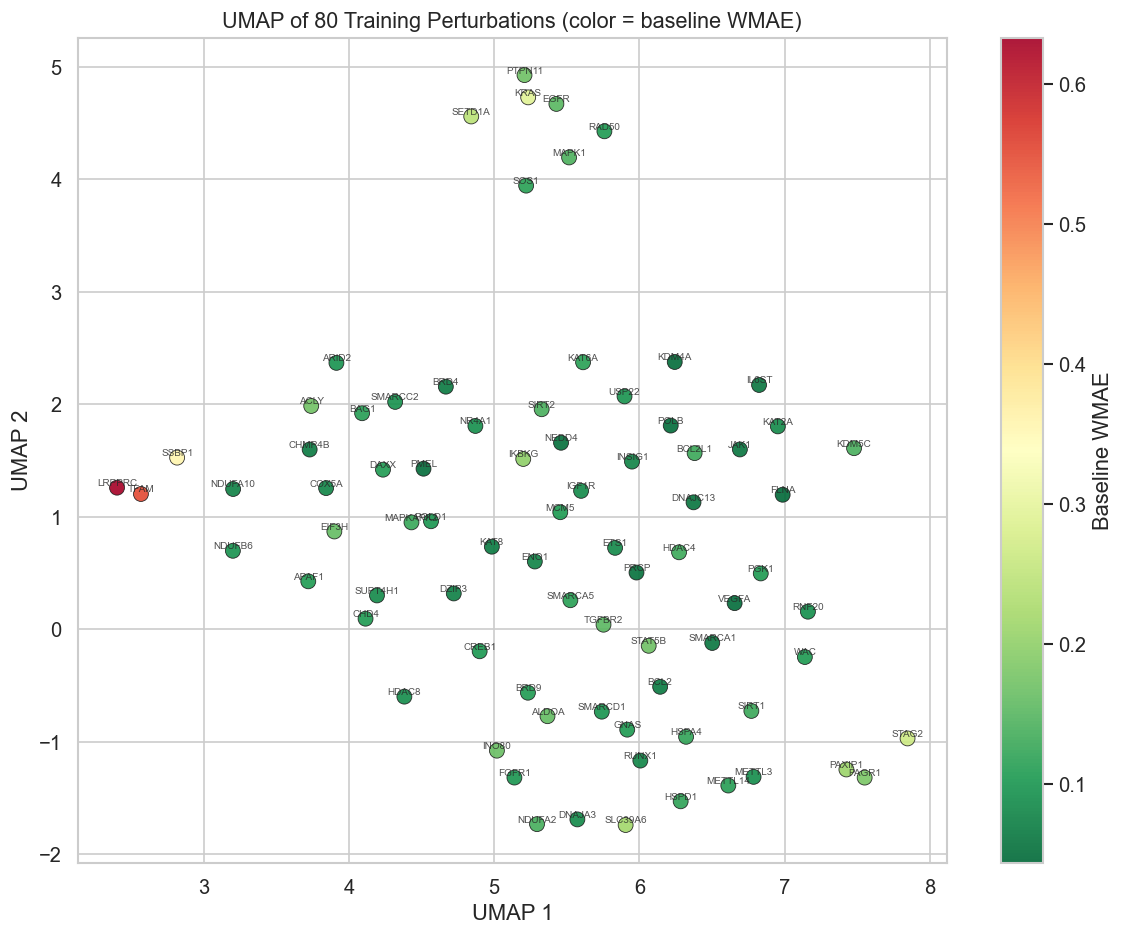

In [7]:
try:
    import umap
    
    reducer = umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.3, random_state=config.SEED)
    embedding = reducer.fit_transform(de_matrix)  # (80, 2)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(embedding[:, 0], embedding[:, 1],
                    c=baseline_wmae_per_pert.set_index('pert_id').reindex(pert_order)['baseline_wmae'].values,
                    cmap='RdYlGn_r', s=80, alpha=0.9, edgecolors='k', linewidths=0.5)
    
    for i, gene in enumerate(pert_order):
        ax.annotate(gene, (embedding[i, 0], embedding[i, 1]),
                    fontsize=6, alpha=0.8, ha='center', va='bottom')
    
    plt.colorbar(sc, ax=ax, label='Baseline WMAE')
    ax.set_title('UMAP of 80 Training Perturbations (color = baseline WMAE)', fontsize=13)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, '05_umap_perts.png'), bbox_inches='tight')
    plt.show()
except ImportError:
    print('umap-learn not installed (pip install umap-learn). Skipping UMAP.')

## 7. STRING Network Subgraph (Perturbation Genes)

/Users/luj12/Desktop/PROJECTS/Kaggle/Myllia_Perturb/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loading cached STRING interactions from /Users/luj12/Desktop/PROJECTS/Kaggle/Myllia_Perturb/external/string_interactions.tsv …
  48785 interactions loaded
Graph: 200 nodes, 743 edges
Connected components: 28


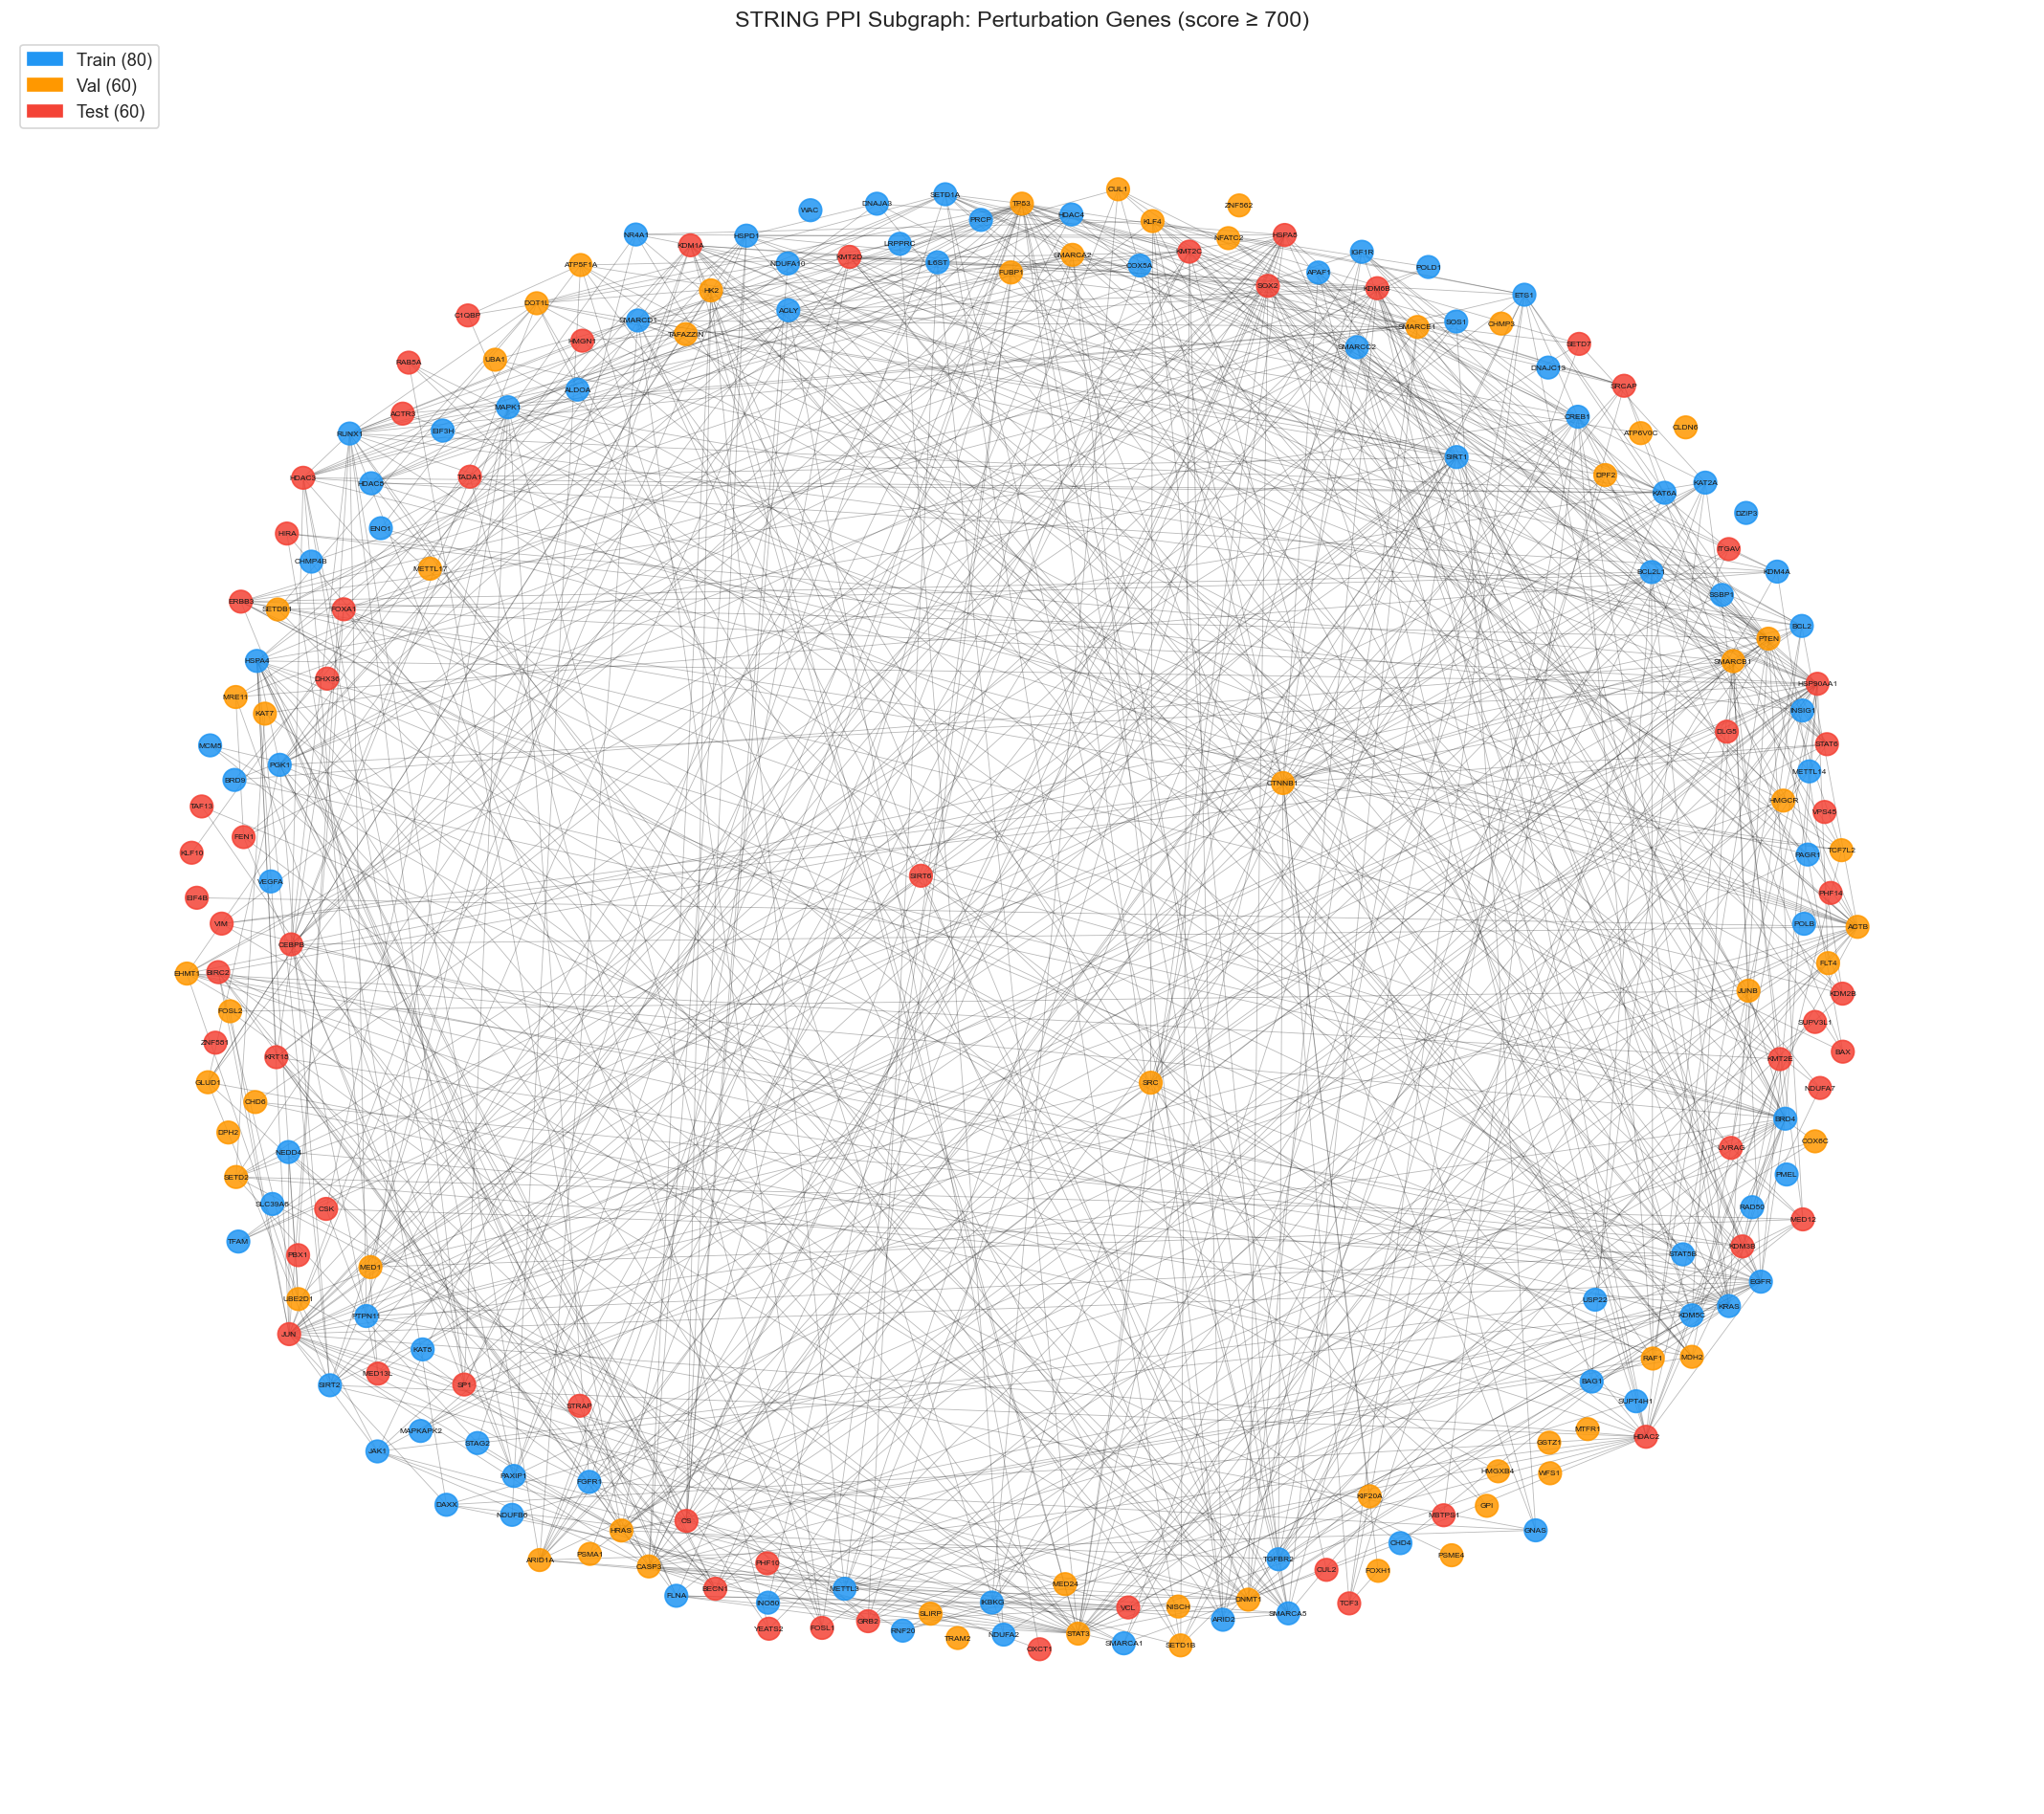

In [8]:
import networkx as nx
from graph_builder import download_string_interactions

all_pert_genes = list(set(pert_order) | set(perts_all['pert'].tolist()))
string_df = download_string_interactions(all_pert_genes, score_threshold=700)

# Build networkx graph
G = nx.Graph()
G.add_nodes_from(all_pert_genes)
for _, row in string_df.iterrows():
    a, b, s = row['gene_a'], row['gene_b'], float(row['score'])
    if a in set(all_pert_genes) and b in set(all_pert_genes):
        G.add_edge(a, b, weight=s)

print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Connected components: {nx.number_connected_components(G)}')

# Plot
train_set = set(pert_order)
val_set   = set(perts_all[perts_all['class']=='val']['pert'].tolist())
test_set  = set(perts_all[perts_all['class']=='test']['pert'].tolist())

node_colors = []
for n in G.nodes():
    if n in train_set:
        node_colors.append('#2196F3')   # blue = train
    elif n in val_set:
        node_colors.append('#FF9800')   # orange = val
    else:
        node_colors.append('#F44336')   # red = test

fig, ax = plt.subplots(figsize=(18, 16))
pos = nx.spring_layout(G, seed=config.SEED, k=2.5)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=200, alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=5, ax=ax)
edges = G.edges(data=True)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5, ax=ax)

from matplotlib.patches import Patch
legend = [
    Patch(color='#2196F3', label='Train (80)'),
    Patch(color='#FF9800', label='Val (60)'),
    Patch(color='#F44336', label='Test (60)'),
]
ax.legend(handles=legend, fontsize=11, loc='upper left')
ax.set_title('STRING PPI Subgraph: Perturbation Genes (score ≥ 700)', fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '06_string_network.png'), bbox_inches='tight', dpi=150)
plt.show()

## 8. Gene Similarity Heatmap (Train ↔ Test)

Loading cached STRING interactions from /Users/luj12/Desktop/PROJECTS/Kaggle/Myllia_Perturb/external/string_interactions.tsv …
  48785 interactions loaded
STRING similarity matrix: (120, 80)
  Genes with at least 1 STRING hit: 90 / 120


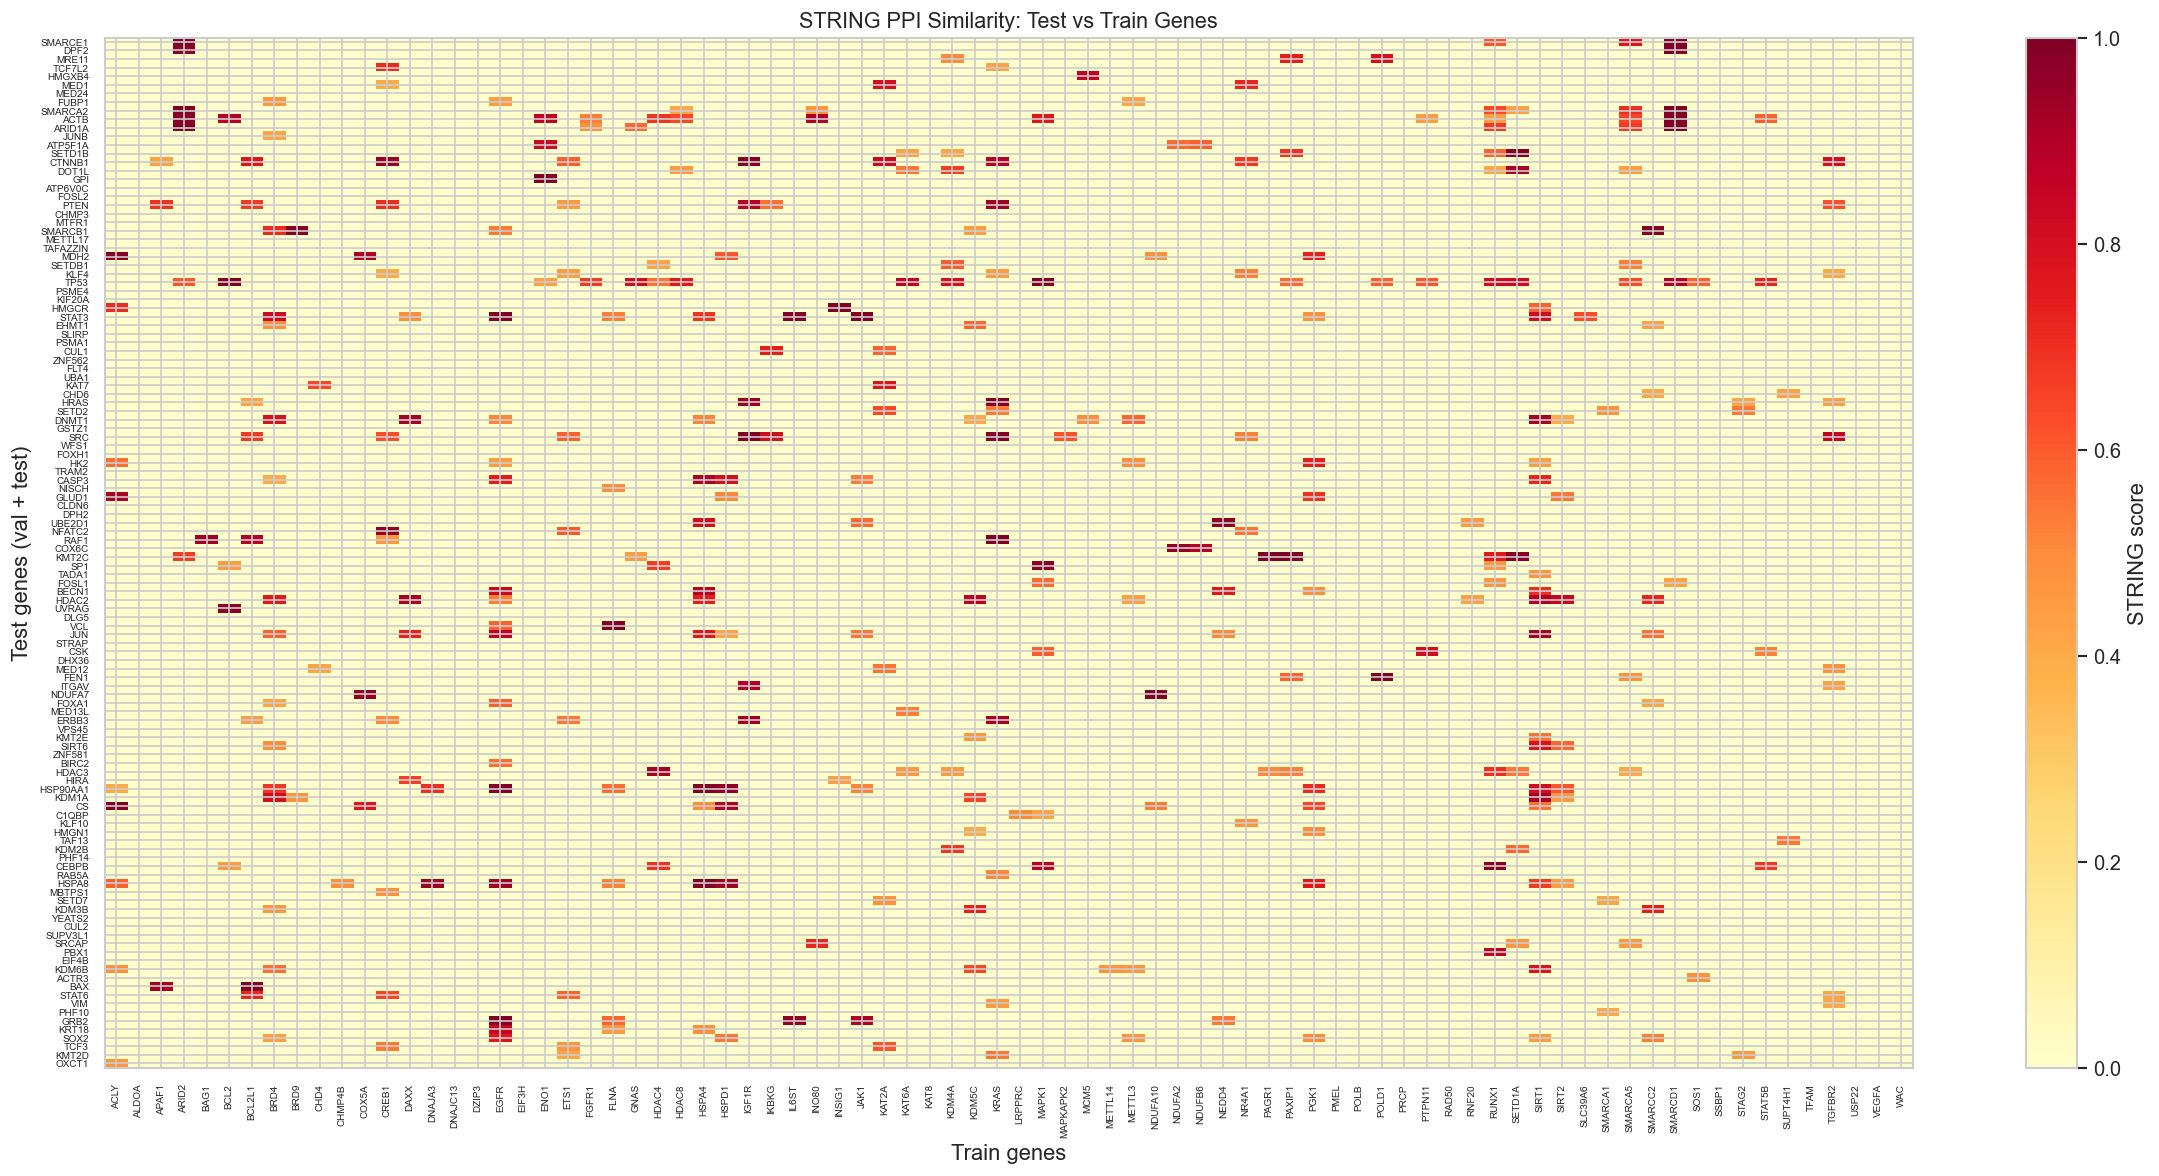

Test genes with ≥1 STRING hit (score ≥ 0.4): 90 / 120
Test genes with NO STRING hit:                30 / 120


In [9]:
# STRING similarity between test genes (val+test) and training genes
from knn_baseline import build_string_similarity

test_genes_ordered = perts_all['pert'].tolist()
sim_matrix = build_string_similarity(test_genes_ordered, pert_order)

# Plot heatmap (test × train)
fig, ax = plt.subplots(figsize=(20, 10))
im = ax.imshow(sim_matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_yticks(range(len(test_genes_ordered)))
ax.set_yticklabels(test_genes_ordered, fontsize=6)
ax.set_xticks(range(len(pert_order)))
ax.set_xticklabels(pert_order, rotation=90, fontsize=6)
ax.set_ylabel('Test genes (val + test)')
ax.set_xlabel('Train genes')
ax.set_title('STRING PPI Similarity: Test vs Train Genes', fontsize=13)
plt.colorbar(im, ax=ax, label='STRING score')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '07_gene_similarity_heatmap.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f'Test genes with ≥1 STRING hit (score ≥ 0.4): {(sim_matrix.max(axis=1) >= 0.4).sum()} / {len(test_genes_ordered)}')
print(f'Test genes with NO STRING hit:                {(sim_matrix.max(axis=1) == 0).sum()} / {len(test_genes_ordered)}')

## 9. Cell Type / Batch Distribution

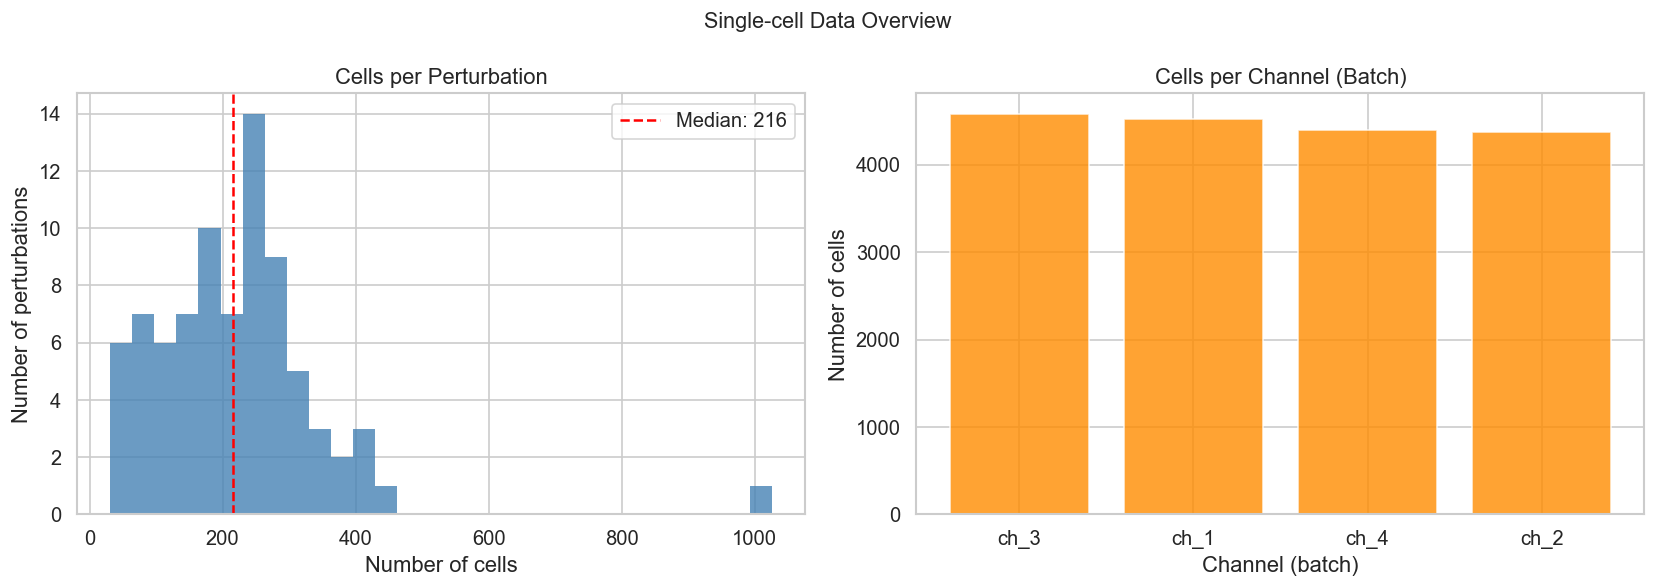

Total cells:      17882
Perturbations:    81 (incl. non-targeting)
Control cells:    1026
Mean cells/pert:  221


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cells per perturbation
cells_per_pert = adata.obs['sgrna_symbol'].value_counts()
axes[0].hist(cells_per_pert.values, bins=30, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].set_xlabel('Number of cells')
axes[0].set_ylabel('Number of perturbations')
axes[0].set_title('Cells per Perturbation')
axes[0].axvline(cells_per_pert.median(), color='red', linestyle='--', label=f'Median: {cells_per_pert.median():.0f}')
axes[0].legend()

# Channel distribution
channel_counts = adata.obs['channel'].value_counts()
axes[1].bar(channel_counts.index, channel_counts.values, color='darkorange', alpha=0.8)
axes[1].set_xlabel('Channel (batch)')
axes[1].set_ylabel('Number of cells')
axes[1].set_title('Cells per Channel (Batch)')

plt.suptitle('Single-cell Data Overview', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, '08_cell_distribution.png'), bbox_inches='tight')
plt.show()

print(f'Total cells:      {adata.n_obs}')
print(f'Perturbations:    {cells_per_pert.shape[0]} (incl. non-targeting)')
print(f'Control cells:    {cells_per_pert.get("non-targeting", 0)}')
print(f'Mean cells/pert:  {cells_per_pert.mean():.0f}')

## 10. Summary Statistics

In [11]:
print('=' * 50)
print('COMPETITION SUMMARY')
print('=' * 50)
print(f'Training perturbations: {de_matrix.shape[0]}')
print(f'Output genes:           {de_matrix.shape[1]}')
print(f'Test perturbations:     {len(perts_all)}')
print(f'  val (GT available):   {(perts_all["class"]=="val").sum()}')
print(f'  test (blind):         {(perts_all["class"]=="test").sum()}')
print()
print('DE value statistics:')
print(f'  Mean:     {de_matrix.mean():.4f}')
print(f'  Std:      {de_matrix.std():.4f}')
print(f'  |DE|>0.1: {(np.abs(de_matrix)>0.1).mean()*100:.1f}%')
print()
print('Baseline WMAE: 0.1268 (mean DE vector)')
print('Zero WMAE:     ~0.1413')
print()
print('Figures saved to:', FIGURES)
for fn in sorted(os.listdir(FIGURES)):
    print(f'  {fn}')

COMPETITION SUMMARY
Training perturbations: 80
Output genes:           5127
Test perturbations:     120
  val (GT available):   60
  test (blind):         60

DE value statistics:
  Mean:     -0.0018
  Std:      0.0569
  |DE|>0.1: 5.4%

Baseline WMAE: 0.1268 (mean DE vector)
Zero WMAE:     ~0.1413

Figures saved to: /Users/luj12/Desktop/PROJECTS/Kaggle/Myllia_Perturb/outputs/figures
  01_de_distribution.png
  02_pert_difficulty.png
  03_de_clustermap.png
  04_weight_distribution.png
  05_umap_perts.png
  06_string_network.png
  07_gene_similarity_heatmap.png
  08_cell_distribution.png
